# IND320 Data to Decision - Compulsory work, part 1

Reading, cleaning and plotting Norwegian hydropower reservoir data (`reservoirs.csv`),
and building a first version of the Streamlit app.

## Links

- **GitHub repository:** https://github.com/limmen20/limmen-streamlit-dashboard
- **Streamlit app:** https://limmen-app-dashboard.streamlit.app/
- **Screencast:** https://youtu.be/k98pbfksDpg

## AI usage

I used an AI assistant (Claude) as a coding helper in this part of the project. It was used to
suggest English names for the Norwegian column headers, draft and draft and comment the pandas/matplotlib code in this notebook, set up the structure of
the multipage Streamlit app (caching, `LineChartColumn`, `selectbox`, `select_slider`) and to
help debug the app.

## Log

The goal of this first part was to set up the tools for the rest of the course and get a first
look at the data. I created a public GitHub repository "limmen-streamlit-dashboard", cloned it
to my computer and connected it to Streamlit Community Cloud by logging in with my GitHub account.
The repository holds both this notebook and the Streamlit app, so the documentation and the online
app are kept together.

In the Jupyter Notebook I read "reservoirs.csv" with pandas. The file contains weekly reservoir
statistics from NVE, from January 1995 to September 2026. The headers are in Norwegian, so I
renamed them to English names such as "filling_ratio", "capacity_TWh" and "filling_TWh". When
looking at the data I found that the file is in "long" format, it contains nine areas (all of
Norway, the five electricity price areas NO1-NO5 and three watercourse regions), and the rows are
not sorted by date. There are no missing values. The reservoir capacity is constant for each
area, so it shows up as a flat line when plotted. To get one clean time series per column I sorted
the data by date and used the "Norway (total)" area for the plots.

I first plotted each measurement column in its own figure, with percentage axes for the ratio
columns. Plotting all columns together was harder, because the ratio columns are between 0 and 1
while capacity and stored energy are measured in TWh. Instead of using two y-axes, which are easy
to misread, I divided each column by its largest absolute value. All columns then share one axis
from -1 to 1 and can be compared by their shape. I limited that plot to the three most recent full
years so the seasonal pattern (reservoirs filling in summer/autumn and emptying in winter/spring)
is easy to see.

The Streamlit app is a multipage app with four pages, where Streamlit builds the sidebar menu from
the "pages/" folder. The data is loaded once in a shared function decorated with
"@st.cache_data", so the CSV is not read again every time a widget changes. The data table page
has one row per data column and uses "LineChartColumn" to show the values from the first month as
a small line chart in each row. The plot page has a "selectbox" for choosing one column or all
columns, and a "select_slider" for choosing a range of months, starting at the first month.
I used Plotly for this plot because it gives hover tooltips and zoom with little extra code. A
sidebar drop-down lets the user choose which area to look at. The fourth page is a placeholder
for later parts, when the CSV file will be replaced by a MongoDB database.

The main things I learned were how to structure a Streamlit multipage app, why caching matters
for app speed, and how to deal with columns that have very different scales in one plot.

## 1. Setup

In [1]:
# Libraries used in this notebook
import pandas as pd                      # reading and handling the data
import matplotlib.pyplot as plt          # plotting
from matplotlib.ticker import PercentFormatter

# Common plot style: white background, light grid behind the data
plt.rcParams.update({
    "figure.figsize": (10, 3.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Read the data

The file `reservoirs.csv` comes from the course material (`D2Dbook/data`) and is stored in the
`data/` folder of this repository, where the Streamlit app also reads it.

In [2]:
# Read the CSV file. The date column is parsed as dates so it can be used on the x-axis.
df = pd.read_csv("data/reservoirs.csv", parse_dates=["dato_Id"])
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (14877, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Rename headers to English

The original headers are Norwegian. They are renamed to short, understandable English names.
The same mapping is used in the Streamlit app (`utils.py`).

| Original | New name | Meaning |
|---|---|---|
| `dato_Id` | `date` | Date of the weekly measurement |
| `omrType` | `area_type` | Area type: NO = Norway, EL = price area, VASS = watercourse region |
| `omrnr` | `area_number` | Area number within the area type |
| `iso_aar` / `iso_uke` | `iso_year` / `iso_week` | ISO year and week |
| `fyllingsgrad` | `filling_ratio` | Share of the reservoir capacity that is filled (0-1) |
| `kapasitet_TWh` | `capacity_TWh` | Total reservoir capacity (TWh) |
| `fylling_TWh` | `filling_TWh` | Stored energy (TWh) |
| `neste_Publiseringsdato` | `next_publication_date` | Date of the next publication |
| `fyllingsgrad_forrige_uke` | `filling_ratio_prev_week` | Filling ratio the week before |
| `endring_fyllingsgrad` | `filling_ratio_change` | Change in filling ratio since the week before |

In [3]:
# Norwegian -> English column names
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_ratio",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filling_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_ratio_prev_week",
    "endring_fyllingsgrad": "filling_ratio_change",
}
df = df.rename(columns=column_names)

# The rows in the file are not in date order, so sort by area and date
df = df.sort_values(["area_type", "area_number", "date"]).reset_index(drop=True)
df.head()

,date,area_type,area_number,iso_year,iso_week,filling_ratio,capacity_TWh,filling_TWh,next_publication_date,filling_ratio_prev_week,filling_ratio_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,0001-01-01T00:00:00,0.621467,-0.038367
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,0001-01-01T00:00:00,0.583100,-0.032496
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,0001-01-01T00:00:00,0.550604,-0.042164
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,0001-01-01T00:00:00,0.508440,-0.039217


## 4. Look at the contents

In [4]:
# Column types and number of non-missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     14877 non-null  datetime64[us]
 1   area_type                14877 non-null  str           
 2   area_number              14877 non-null  int64         
 3   iso_year                 14877 non-null  int64         
 4   iso_week                 14877 non-null  int64         
 5   filling_ratio            14877 non-null  float64       
 6   capacity_TWh             14877 non-null  float64       
 7   filling_TWh              14877 non-null  float64       
 8   next_publication_date    14877 non-null  str           
 9   filling_ratio_prev_week  14877 non-null  float64       
 10  filling_ratio_change     14877 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 1.6 MB


In [5]:
# Summary statistics for the numeric columns
df.describe().round(3)

,date,area_number,iso_year,iso_week,filling_ratio,capacity_TWh,filling_TWh,filling_ratio_prev_week,filling_ratio_change
count,14877,14877.000,14877.000,14877.000,14877.000,14877.000,14877.000,14877.000,14877.000
mean,2010-11-07 00:00:00,2.333,2010.346,26.406,0.619,29.146,18.140,0.619,-0.000
min,1995-01-08 00:00:00,0.000,1995.000,1.000,0.055,6.003,0.331,0.055,-0.242
25%,2002-12-08 00:00:00,1.000,2002.000,13.000,0.456,17.391,7.322,0.456,-0.022
50%,2010-11-07 00:00:00,2.000,2010.000,26.000,0.648,23.238,14.501,0.648,-0.007
75%,2018-10-07 00:00:00,3.000,2018.000,39.000,0.802,34.044,22.204,0.802,0.016
max,2026-09-06 00:00:00,5.000,2026.000,53.000,1.020,87.438,84.545,1.020,0.337
std,NaN,1.491,9.147,15.018,0.215,22.739,15.966,0.215,0.031


In [6]:
# The file contains several areas. Count rows, period and capacity per area.
areas = df.groupby(["area_type", "area_number"]).agg(
    rows=("date", "size"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    capacity_TWh=("capacity_TWh", "mean"),
)
print("Missing values in total:", df.isna().sum().sum())
areas

Missing values in total: 0


rows first_date  last_date  capacity_TWh
area_type area_number                                          
EL        1            1653 1995-01-08 2026-09-06      6.003264
          2            1653 1995-01-08 2026-09-06     34.043590
          3            1653 1995-01-08 2026-09-06      8.920932
          4            1653 1995-01-08 2026-09-06     21.079208
          5            1653 1995-01-08 2026-09-06     17.390587
NO        0            1653 1995-01-08 2026-09-06     87.437580
VASS      1            1653 1995-01-08 2026-09-06     36.044464
          2            1653 1995-01-08 2026-09-06     23.237715
          3            1653 1995-01-08 2026-09-06     28.155403

The data holds **9 areas** with the same 1653 weekly observations each (January 1995 to
September 2026) and no missing values. The capacities of the five price areas (and of the three
watercourse regions) add up to the total for Norway.

For the plots below we use **Norway (total)** (`area_type == "NO"`), so that each column is one
time series. The columns that are measurements (and therefore make sense to plot) are the five
below; the other columns are dates or identifiers.

In [7]:
# Keep only the total for Norway and use the date as index
norway = df[df["area_type"] == "NO"].set_index("date")

# Measurement columns with readable labels, and one fixed colour per column
value_columns = {
    "filling_ratio": "Filling ratio",
    "filling_ratio_prev_week": "Filling ratio previous week",
    "filling_ratio_change": "Change in filling ratio since previous week",
    "filling_TWh": "Stored energy (TWh)",
    "capacity_TWh": "Reservoir capacity (TWh)",
}
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
ratio_columns = ["filling_ratio", "filling_ratio_prev_week", "filling_ratio_change"]

norway[list(value_columns)].tail()

,filling_ratio,filling_ratio_prev_week,filling_ratio_change,filling_TWh,capacity_TWh
date,,,,,
2026-08-09,0.641443,0.628032,0.013411,56.086210,87.43758
2026-08-16,0.647891,0.641444,0.006447,56.649975,87.43758
2026-08-23,0.639520,0.647891,-0.008371,55.918064,87.43758
2026-08-30,0.634381,0.639524,-0.005144,55.468720,87.43758
2026-09-06,0.636054,0.634421,0.001633,55.615055,87.43758


## 5. Plot each column separately

One figure per measurement column, for the whole period. The ratio columns are shown as
percentages.

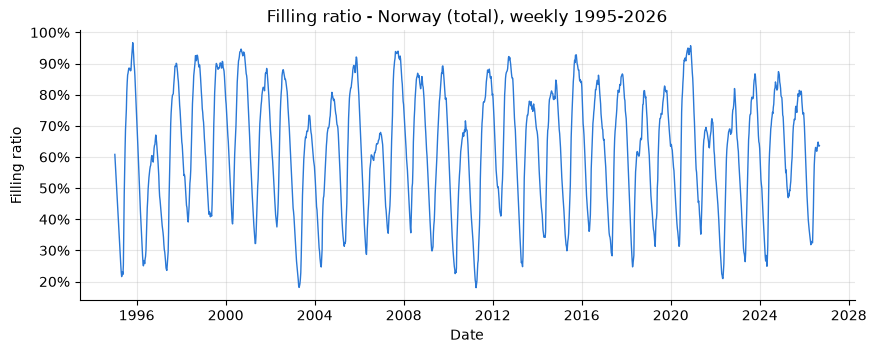

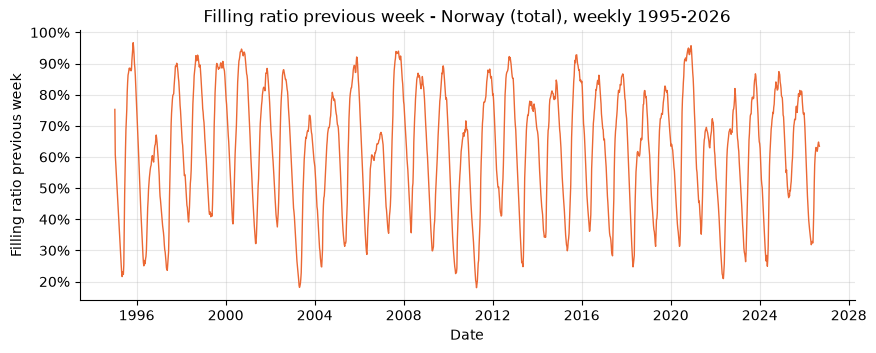

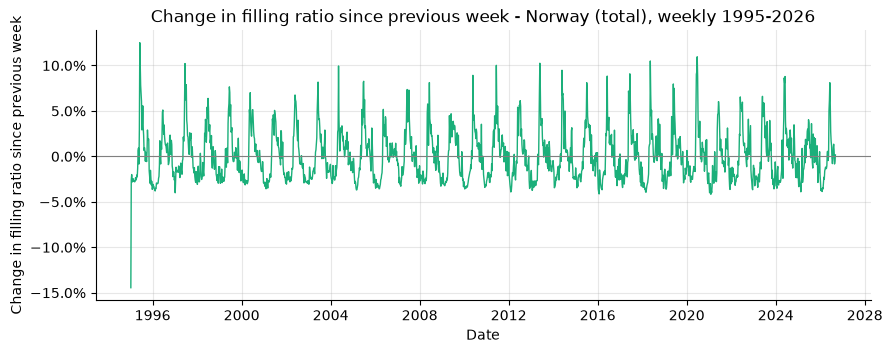

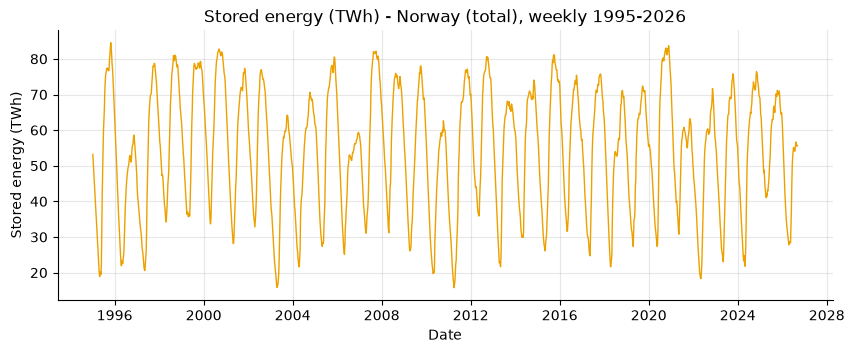

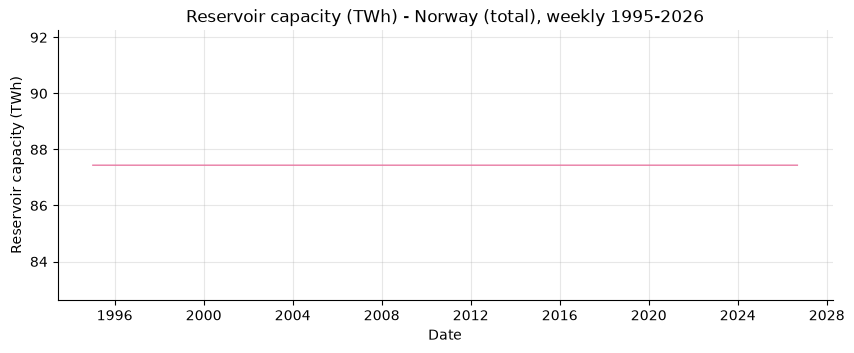

In [8]:
for (col, label), color in zip(value_columns.items(), colors):
    fig, ax = plt.subplots()
    ax.plot(norway.index, norway[col], color=color, linewidth=1)
    ax.set_title(f"{label} - Norway (total), weekly 1995-2026")
    ax.set_xlabel("Date")
    ax.set_ylabel(label)
    if col in ratio_columns:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))  # 0.5 -> 50 %
    if col == "filling_ratio_change":
        ax.axhline(0, color="grey", linewidth=0.8)  # reference line at zero change
    plt.show()

The filling ratio and stored energy follow a clear yearly cycle: the reservoirs fill up during
snow melt in late spring and summer and are emptied during winter. The capacity is constant over
the whole period, so it is a flat line. The weekly change is positive in summer and negative in
winter.

## 6. Plot all columns together

The columns have very different scales: the ratios are between 0 and 1 (or around 0 for the
change), while stored energy and capacity are up to about 87 TWh. Plotted on the same axis, the
ratio columns would be flat lines at the bottom. A second y-axis is easy to misread, so instead
**each column is divided by its largest absolute value**. All columns then lie between -1 and 1
and can be compared by their shape on one shared axis. (Min-max scaling does not work here,
because the capacity is constant.)

To keep the lines readable, the plot shows the three most recent full years (2023-2025).

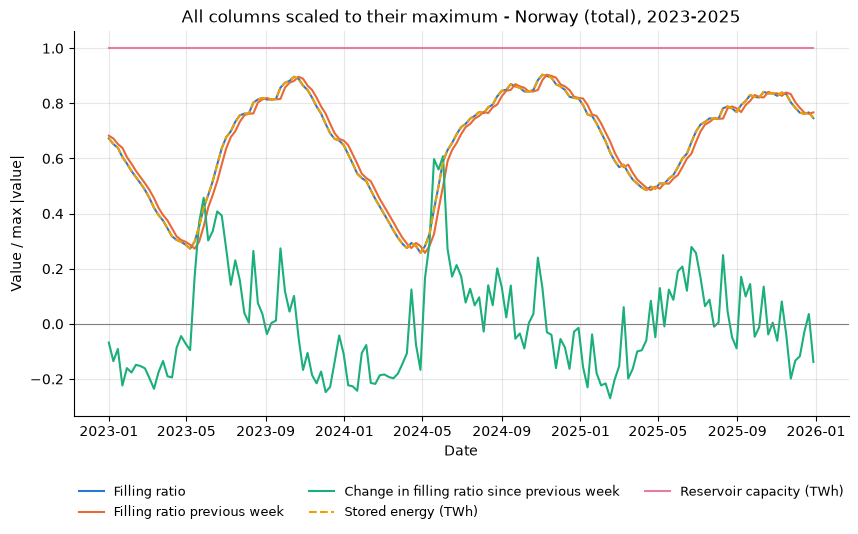

In [9]:
# Scale each column by its maximum absolute value (over the whole period)
scaled = norway[list(value_columns)] / norway[list(value_columns)].abs().max()
recent = scaled.loc["2023-01-01":"2025-12-31"]

fig, ax = plt.subplots(figsize=(10, 5))
for (col, label), color in zip(value_columns.items(), colors):
    # Stored energy is dashed, because after scaling it lies on top of the filling ratio
    style = "--" if col == "filling_TWh" else "-"
    ax.plot(recent.index, recent[col], label=label, color=color, linewidth=1.5, linestyle=style)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("All columns scaled to their maximum - Norway (total), 2023-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Value / max |value|")
# Legend below the plot so it does not hide any lines
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9, frameon=False)
plt.show()

The filling ratio and stored energy (dashed) lie on top of each other, since stored energy is
simply the filling ratio times the (constant) capacity. The previous week's filling ratio is the same curve
shifted by one week, and the change is largest when the curves are steepest.